<a href="https://colab.research.google.com/github/SimonTarberg/Lab1_numpy/blob/main/Lab1_HT25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Note: This Lab uses and extends material from the first Lab in DT1130 (Spectral Transforms)

# DM1135 Lab 1: Introduction

In this course, all labs will be performed in Google Colab! This is a lab introduction so that you can become comfortable with Google Colab and various operations that are important to be able to complete the course's labs.

The first thing you should do is save a copy of this lab guide as it is read-only. This can be done by *File* -> *Save a copy in drive*.

### Load the data

Download the [labdata](https://drive.google.com/file/d/1pVMem42hqZ3ZdFALem6bytKM1cVCTCKR/view?usp=sharing) if you have not already done so. It contains sound files, among others, on which you can test your filters. The section "Working with Files" below explains how to load them!

# Support

Please post questions on canvas, in the pinned discussion related to Lab 1.


# Background: Getting started

In [86]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### First example

The first thing we're going to do is run a *cell*. A cell contains python code (or text, the text you're reading here is written in a text cell!). In Google Colab, you run a cell by being in it and pressing the "play" button or pressing ctrl-enter. The result of running the cell appears below it.

**Now try running the cell below**.

In [ ]:
1 + 1

2

### The last row

The last line of a Google Colab cell is a bit special. If you run something that returns a value, such as 1+1 above, it will automatically print the result. However, if you were to run $a = 1+1$, which does not return a value in Python, nothing will be displayed, and you will have to use the *print* function to print the value instead.

In [ ]:
a = 1 + 1
print(a)

2


### Cells depend on previously run cells
(NOTE! make sure you have run the cell above before doing this task) Since in the cell above we ran $a = 1+1$, the value of $a$ can now be used in other cells.

**Try running the cell below to see this!**

In [ ]:
a + 4

6

### Importing libraries
Now we are going to import a couple of important libraries. Libraries usually need to be installed on the computer, but since we are using Google Colab, it already comes pre-installed with common libraries. We will start by importing a very common library called "numpy". A library for vector and matrix operations.


In [ ]:
import numpy

a = numpy.array([3,3])  # skapar en array. Detaljerna är inte viktiga här utan endast att det fungerade att importera biblioteket.
print(a)

[3 3]



You can import libraries with a shorter name by adding "*as*" to the import statement. This is demonstrated below by importing the popular library numpy but giving it the abbreviation "np".

(numpy is a very common library in the python world and is generally always imported as "np")

In [ ]:
import numpy as np

b = np.array([3,3])
print(b)

[3 3]


Most examples found on the internet assume that they have been imported this way and many well-known libraries have their own "classic" abbreviations.

When you run a cell, the result can be used in subsequent cells. This means that you only need to load these libraries once and can use them throughout the rest of your Google Colab document.
**Run the cell below to import these libraries**

In [ ]:
import numpy as np                # Numpy används för bland annat matrisoperationer
import matplotlib.pyplot as plt   # Matplotlib används för att visa plottar
import scipy.io.wavfile           # Används för att ladda in ljud
import imageio                    # Används för att ladda in bilder
from IPython.display import Audio # Används för att kunna spela upp ljud.

print("Alla bibliotek importerades som de skulle!")

Alla bibliotek importerades som de skulle!


### Plot something
In some of the tasks it will be necessary to plot things. The example below shows how to do this.

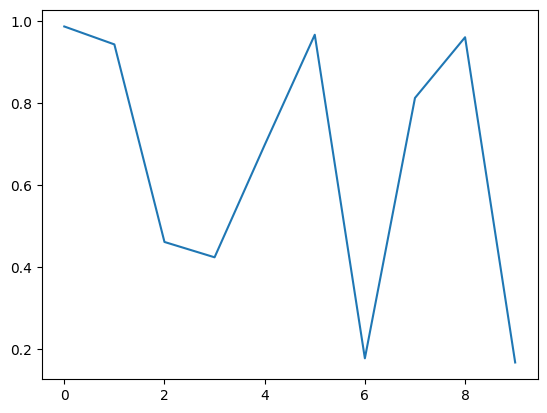

In [ ]:
line = np.random.rand(10) # Ger oss 10 slumpmässiga värden som en vektor
plt.plot(line)

### Changing variables

In [ ]:
# @title { run: "auto" }
x = 43 #@param {type: "slider", min: 0, max: 100}
y = 20 #@param {type: "slider", min: 0, max: 100}
print(f"{x} + {y} = {x+y}")

43 + 20 = 63


### Working with files
To load files, click the gray arrow button on the left to expand the side panel. Then click *Files* and then *UPLOAD* to upload a file. This file can then be loaded and worked with. **Upload the file simple.txt and run the code example below**.

In [ ]:
with open('/content/sample_data/simple.txt') as f:
  print(f.read())

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/simple.txt'

### Play back sound

In [ ]:
# @title { run: "auto" }
samplingsfrekvens = 20000
tid = 2
frekvens = 272 #@param {type: "slider", min: 100, max: 2000}
t = np.linspace(0, tid, samplingsfrekvens * tid)
sinuston = np.sin(frekvens * 2 * np.pi * t)

Audio(sinuston, rate=samplingsfrekvens)

### Load an image
To load an image, use the `imageio` package and the `imread()` function. It can then be displayed with *plt.imshow*. If you use grayscale images, you must set the *color mapping* to gray through the keyword argument *cmap='gray'*, otherwise images may appear a bit strange. Feel free to try to see what happens when you don't use cmap.

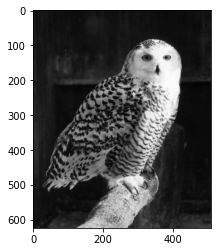

In [ ]:
bild = imageio.imread('/content/sample_data/uggla.tif')
plt.imshow(bild, cmap='gray')

### All at once!

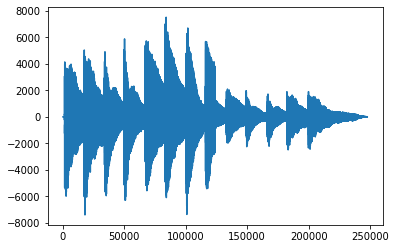

In [ ]:
# @title { run: "auto" }

ljudvolym = 33 #@param {type: "slider", min: 0, max: 100}

# Vi läser in en ljudfil med hjälp av scipy
samplingsfrekvens, audio = scipy.io.wavfile.read('/content/sample_data/whole-tone-scale.wav')

# Då vi har två kanaler tar vi medelvärdet av dessa för att skapa en monosignal
mono_audio = np.mean(audio, axis=1)

# Vi hittar positionen för mitten av ljudvektorn. Notera att vi måste göra
# om den till en int utifall att resultatet inte hade blivit ett heltal
half_audio_length = int(len(mono_audio)/2)

# Vi multiplicerar allt efter positionen för mitten av ljudvektorn med
# volymen (delat på 100 då vi vill ha ett värde mellan 0 och 1).
mono_audio[half_audio_length:] *= ljudvolym/100

# Vi plottar ljudfilen
plt.plot(mono_audio)

# Och gör den uppspelningsbar
Audio(mono_audio, rate=samplingsfrekvens)

## Important Information!

When programming you are constantly encountering things you don't know or things that go wrong. This will happen ALL THE TIME no matter how good you become!

The important thing to learn is how to **FIND** information on how to do things and **NOT** to learn everything by heart. Google is your friend but don't be afraid to go in and look directly at the documentation relevant to the code in question.

The internet is full of great tutorials on everything to do with code. Search google for examples, for tutorials, "python for beginners", look for video tutorials on youtube (there are many!). The internet is full of helpful resources!

# Getting started with Numpy


## Numpy documentation
**Use the documentation!** Many of the tasks you will encounter require you to look up the right function yourself. All functions are well documented in the numpy documentation. If you ever wonder what a function does or what arguments it takes, the documentation is the first place to look for information, not a lab assistant! :-) In Google Colab you can also type the function name followed by a question mark and run the cell to bring up the documentation for that command. Let's start by trying it out!

In [ ]:
np.array?

You can also go to the numpy website where more readable documentation is available,

https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.array.html

Note that at the bottom of the page there are executable code examples, these are usually really good!



## Vectors and Matrices
The way to create an empty matrix or vector in numpy is to use *np.array*. Note that there is an *np.matrix* but *np.array* is just as good but usually a little easier to use.

You create a vector by specifying a list, and a matrix by specifying a list of lists, e.g.:

```
a_column_vector = np.array([1,2,3,4])
a_row_vector = np.array([[1,2,3,4]])
a_matrix = np.array([[1,2], [3,4]])
```

$
a\_column\_vector =\begin{bmatrix}
  1 \\
  2 \\
\end{bmatrix} \\
a\_row\_vector =\begin{bmatrix}
  1 & 2
\end{bmatrix} \\
a\_matrix =\begin{bmatrix}
  1 & 2 \\
  3 & 4 \\
\end{bmatrix}
$






### **1. Exercise:** Create a matrix with the following content

$\begin{bmatrix}
  7.1 & 2. & 4.3 \\
  3. & 4.2 & -1.3 \\
  1. & 1.9 & 0 \\
\end{bmatrix}
$

Remember that if you add a variable (like a_matrix) above, you must use *print* to print the value in the variable.

In [5]:
import numpy as np
 # Put your code here

x = np.array(([7.1,2,4.3], [3,4.2,-1.3],[1,1.9,0]))
print(x)

[[ 7.1  2.   4.3]
 [ 3.   4.2 -1.3]
 [ 1.   1.9  0. ]]


## Complex!
Python has built-in support for arithmetic with **complex numbers**.

*Example:* $j(1-2j) + (1+j)^2$ is written directly as


In [ ]:
1j*(1-2j)*(1+1j)**2

(-2+4j)

If you want to perform mathematical functions with complex numbers, you use the `cmath` module.
Example: $e^{j\pi} + \sqrt {1-j} $ is written as

In [ ]:
import cmath
cmath.exp(1j*cmath.pi) + cmath.sqrt(1-1j)

(0.09868411346781003-0.4550898605622272j)

In Numpy, you can use complex numbers in matrices and in the built-in functions.

*Example:* $ a =\begin{bmatrix}
e^0 & e^{j\pi/2} & e^{j\pi} & e^{j3\pi/2}
\end{bmatrix}$

you can write as

In [ ]:
a = np.array((0,1,2,3))
np.exp(a * 1j * np.pi/2)

array([ 1.0000000e+00+0.0000000e+00j,  6.1232340e-17+1.0000000e+00j,
       -1.0000000e+00+1.2246468e-16j, -1.8369702e-16-1.0000000e+00j])

### **2. Exercise:** Eulers formula

Calculate Eulers formula $$f(\alpha) = \frac{e^{j\alpha} + e^{-j\alpha}}{2}$$ by plotting it as a function of $\alpha$ in the interval $0 \le \alpha \le 2\pi$


<function matplotlib.pyplot.show(close=None, block=None)>

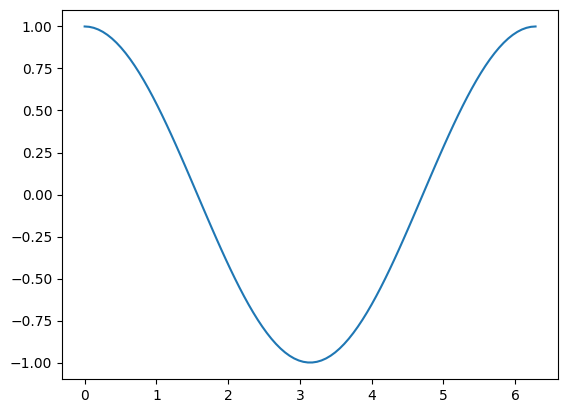

In [10]:
import matplotlib.pyplot as plt
import numpy as np

 # Put your code here
x = np.linspace(0,np.pi*2,100)
x = np.linspace(0, 2*np.pi, 100)
y = (np.exp(1j*x) + np.exp(-1j*x)) / 2
plt.plot(x,y)
plt.show

## Creating Matrices and Vectors
There are many different ways to create vectors and matrices. When creating them, you specify the length you want in each dimension, i.e., if you want to create a vector of length 9, you just specify 9, if you want to create a 4x9 matrix, you specify the lengths 4 and 9. You don't have to limit yourself to just vectors and matrices, you can use any dimensionality you want (e.g., 8x9x5x4 (4 dimensions)).

To create a 2d matrix with only zeros, you can use [np.zeros](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.zeros.html) where the lengths and dimensions are what make up the first argument "shape". You specify it as a "tuple" and if we want to create a matrix with 4 rows and 9 columns, we specify (4,9) as shape

Similarly, you can create a vector of only ones with [np.ones](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.ones.html). When we define shape in one dimension, we still use a tuple, but with only one element. In order for Python to distinguish between a tuple (with one element) and just a regular expression that has parentheses around it, we specify the tuple with a comma after the value, which looks a bit funny, but that's how it's done. So if we want to create a vector of length 9, we specify (9,) as shape.



### **3. Exercise:** Create the matrices below using what you have just learnt.

$\begin{bmatrix}
  0 & 0 & 0 & 0 & 0 & 0 & 0
\end{bmatrix}$


$\begin{bmatrix}
  1 & 1 & 1 & 1 \\
  1 & 1 & 1 & 1 \\
  1 & 1 & 1 & 1 \\
\end{bmatrix}$

In [15]:
 # Put your code here
matrix = np.ones((3,4),int)
print(matrix)

[[1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]]


## Random Matrix
Sometimes you want to quickly create a matrix of random numbers. In that case, you can use [numpy.random.randint](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.randint.html) to create a matrix of a certain size, filled with integers within a certain range.



:### **4. Exercise: Create a 7x7 matrix with random numbers between 8 and 34**

In [23]:
 # Put your code here
np.random.randint(8, high = 34 , size=(7, 7))


array([[25,  8, 26, 31, 13, 12, 33],
       [20, 17, 33, 31, 30, 14, 20],
       [15, 20, 28, 24, 24, 23, 13],
       [18, 30, 25,  8, 24, 27, 28],
       [17, 14, 18, 16, 23, 32, 32],
       [20,  9, 32, 15, 15, 10, 28],
       [22, 26, 15, 32, 18, 21, 30]])

## Picking out rows and columns

Sometimes you want to access certain columns and rows in a matrix.

$A = \begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 9 \\
\end{bmatrix}
$

Numpy uses "axes" to refer to rows and columns. The first axis refers to rows and the second to columns (you can also have more axes, but it is easiest to explain in two dimensions)
To get out a part of a matrix, you use square brackets $[row, column]$ on the variable. Where $row$ and $column$ are either an index or a range. To express a range, use colons $:$ with $start:end$. A quick way to say from start to end is to just enter a colon, or you can say from index 1 to the end by writing $1:$.



Some examples:

**First row:**

`A[0,:] = ` $\begin{bmatrix} 1 &  2 &  3\end{bmatrix}, \quad$     0:th row,  all columns

**Second row:**

`A[1,:] = ` $\begin{bmatrix} 4 &  5 &  6\end{bmatrix}, \quad$       1:st row, all columns

**First and second row:**

`A[:2,:] = `  $\begin{bmatrix} 1 & 2 &  3\\ 4 &  5 &  6\end{bmatrix}, \quad$ up until 2nd row. Row 0 and 1 (not 2), all columns


**First column:**

`A[:,0] = `  $\begin{bmatrix} 1 \\  4 \\  7 \\\end{bmatrix}, \quad$ all rows, 0:th column

**Last column:**

`A[:,-1] = `  $\begin{bmatrix} 3 \\  6 \\  9 \\\end{bmatrix}, \quad$, all rows, last column

**2nd and 3rd column:**

`A[:,1:] =` $\begin{bmatrix}  1 & 2 \\  4 & 5 \\  7 & 8 \\\end{bmatrix}, \quad$ all rows and column 1 and upwards



Let us see how to do that in Numpy:

In [24]:
# Create matrix A from above

A = np.arange(1, 10).reshape(3,3)  # vektor från 1-9 som sedan omformas till en 3x3-matris
print(A)
print('A shape: ', A.shape)  # alla numpy array:er har en shape

[[1 2 3]
 [4 5 6]
 [7 8 9]]
A shape:  (3, 3)


In [25]:
print('första raden: ', A[0,:])
print('andra raden: ', A[1,:])
print('första och andra raden:\n', A[:2,:])  # \n betyder ny rad

första raden:  [1 2 3]
andra raden:  [4 5 6]
första och andra raden:
 [[1 2 3]
 [4 5 6]]


In [26]:
print('första kolumnen: ', A[:, 0])
print('sista kolumnen: ', A[:, -1])

första kolumnen:  [1 4 7]
sista kolumnen:  [3 6 9]


In [28]:
# det går att spara de olika element vi väljer ut i nya array:er

rad_ett = A[0,:]
kolumn_två = A[:, 1]  # vi märker att numpy arrayer börjar på index 0

print('rad ett: ', rad_ett)
print('kolumn två: ', kolumn_två)

rad ett:  [1 2 3]
kolumn två:  [2 5 8]



### **5. Exercise: Matrix addressing**

Create a 5x5 random matrix and take out the elements in the middle to a new variable, which will then contain a 3x3 matrix.

\begin{bmatrix}
  1 & 2 & 3 & 0 & 3 \\
  4 & \textbf{5} & \textbf{6} & \textbf{1} & 1 \\
  7 & \textbf{8} & \textbf{2} & \textbf{2} & 3 \\
  3 & \textbf{1} & \textbf{8} & \textbf{3} & 5 \\
  7 & 4 & 9 & 2 & 4 \\
\end{bmatrix}


In [42]:
 # Put your code here
matris = np.random.randint(9 , size=(5, 5))
print(matris)
print("\n")

ny_matris = matris[1:4,1:4]
print(ny_matris)


[[5 5 0 6 6]
 [0 6 4 7 5]
 [3 0 3 2 2]
 [4 7 3 4 2]
 [4 6 0 7 6]]


[[6 4 7]
 [0 3 2]
 [7 3 4]]


## Vectorized Operations
A good example of how useful Numpy is is when we can perform vectorized operations.

First, we do the same operation in regular Python.




### **6. Exercise: Matrix operations**

Write a function that can take two matrices (a list of lists in regular Python) and add them together element-wise as in the example below. The function should handle matrices of arbitrary size (however, both matrices are always the same size)

$A = \begin{bmatrix}
  1 & 2 \\
  3 & 4 \\
\end{bmatrix}
$

$B = \begin{bmatrix}
  5 & 6 \\
  7 & 8 \\
\end{bmatrix}
$

$A + B = \begin{bmatrix}
  6 & 8 \\
  10 & 12 \\
\end{bmatrix}
$

In [54]:
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]

def addera_matriser(matris_1, matris_2):
  # put code for addition here
  result = []
  for row_a, row_b in zip(A, B):
      new_row = [a + b for a, b in zip(row_a, row_b)]
      result.append(new_row)
  return result
addera_matriser(A, B)

[[6, 8], [10, 12]]

The same operation in Numpy below:

In [55]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

A + B

array([[ 6,  8],
       [10, 12]])

Det är allt! Bra mycket lättare än att behöva loopa sig igenom allt.
I de flesta labbuppgifter ni stöter på i denna kurs går det att slippa att skriva krångliga for-loopar och istället använda en snygg (och mer beräkningseffketiv) vektoriserad lösning, som den ni såg ovan.

## Matematiska operationer med matriser
Here are some common vector and matrix operations and how to perform them with numpy.


### Addition

$A + B = \begin{bmatrix}
  6 & 8 \\
  10 & 12 \\
\end{bmatrix}
$

### Subtraction

$A - B = \begin{bmatrix}
  -4 & -4 \\
  -4 & -4 \\
\end{bmatrix}
$

### Multiplication with a scalar
*Note that this multiplies all elements in the matrix with the scalar.*

$A * 2 = \begin{bmatrix}
  A_{00}*2 & A_{01}*2 \\
  A_{10}*2 & A_{11}*2 \\
\end{bmatrix} = \begin{bmatrix}
  2 & 4 \\
  6 & 8 \\
\end{bmatrix}
$


### Division with scalar

$A/2 = \begin{bmatrix}
  \frac{A_{00}}{2} & \frac{A_{01}}{2} \\
  \frac{A_{10}}{2} & \frac{A_{11}}{2} \\
\end{bmatrix} = \begin{bmatrix}
  .5 & 1 \\
  1.5 & 2 \\
\end{bmatrix}
$

### Elementwise multiplication with another matrix

$A * B = \begin{bmatrix}
  A_{00} * B_{00} &  A_{01} * B_{01} \\
  A_{10} * B_{10} &  A_{11} * B_{11} \\
\end{bmatrix} = \begin{bmatrix}
  5 &  12 \\
  21 &  32 \\
\end{bmatrix}
$

### Matrix multiplication
With numpy matrix multiplication is done by using the $@$ symbol.

$A@B = AB = \begin{bmatrix}
  19 & 22 \\
  43 & 50 \\
\end{bmatrix}
$



### **7. Exercise: Matrix operations ctd.**

Create the two matrices below and execute all the above operations on them:

$C = \begin{bmatrix}
  4 & 2 \\
  7 & 3 \\
\end{bmatrix}
$

$D = \begin{bmatrix}
  1 & 3 \\
  2 & 9 \\
\end{bmatrix}
$

In [65]:
 # Put your code here
C = np.array([4,2,7,3]).reshape(2,2)
D = np.array([1,3,2,9]).reshape(2,2)

def addition(a,b):
  return a + b

def subtraction(a,b):
  return a - b

def scalar_multiplaction(a,scalar):
  return a * scalar

def scalar_division(a,scalar):
  return a / scalar

def elementwise_multiplication(a,b):
  return a * b

def matrix_multiplaction(a,b):
  return a@b



[[ 8 30]
 [13 48]]


## Matrices, images and audio signals are actually the same thing.
In the tasks below we will work with images and audio signals. You work with images and audio in exactly the same way as a matrix.

This is why in this course we focus on the (mathematically) simplest case: audio signals!

When sound is saved as a file on a computer, it is represented, just like images, as numbers. An audio file can have one, two, or more audio channels. A sound with only one audio channel is called "mono" and a sound with multiple audio channels is called "stereo".

We assume here that all sound is in its simplest form, mono. A mono audio file is then represented as a vector, an array, of intensity values. Before we talk too much about sound, let's revisit the note that was played in the introduction.

In [ ]:
# @title { run: "auto" }
samplingsfrekvens = 20000
tid = 2
frekvens = 412 #@param {type: "slider", min: 100, max: 1000}
t = np.linspace(0, tid, samplingsfrekvens * tid)
sinuston = np.sin(frekvens * 2 * np.pi * t)

# Och gör den uppspelningsbar
Audio(sinuston, rate=samplingsfrekvens)

In [ ]:
# numpy
print('sinuston form: ', sinuston.shape)
print('max: ', sinuston.max())
print('min: ', sinuston.min())

sinuston form:  (40000,)
max:  0.9999999930600875
min:  -0.9999999930600875


Now try adding noise by adding a vector of random values ​​multiplied by `brus_intensitet` to vary how much noise we add to the signal.



In [73]:
from IPython.display import Audio
# @title { run: "auto" }

# brusig sinussignal
# Istället för att endast lyssna på en ren, fint klingande sinuston kan vi tillföra
# lite brus, lite random data.
# @title { run: "auto" }
samplingsfrekvens = 20000
tid = 2
frekvens = 412 #@param {type: "slider", min: 100, max: 1000}
t = np.linspace(0, tid, samplingsfrekvens * tid)
sinuston = np.sin(frekvens * 2 * np.pi * t)

# Och gör den uppspelningsbar
Audio(sinuston, rate=samplingsfrekvens)


brus = 20 #@param {type: "slider", min: 0, max: 100}

brus_intensitet = brus/100

## Skriv din kod nedan!

# skapa slumpvärden i samma storlek som "sinuston"

noise = np.random.normal(0, 1, size=sinuston.shape) * brus_intensitet

# Lägg till brus-datan genom att addera bruset med sinustonen
brusig_sinuston = sinuston + noise


# Spela upp och hör den fina musiken!
Audio(brusig_sinuston, rate=samplingsfrekvens)

## Plotting a matrix
An image and a matrix are essentially the same thing. The image is represented as a 2D matrix in the computer, where the rows and columns correspond to pixels in the image. We can show this in the following way.

**Run the example below**

$A = \begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 9 \\
\end{bmatrix}
$

We then see that the lower values ​​go towards black, and the higher values ​​go towards white.

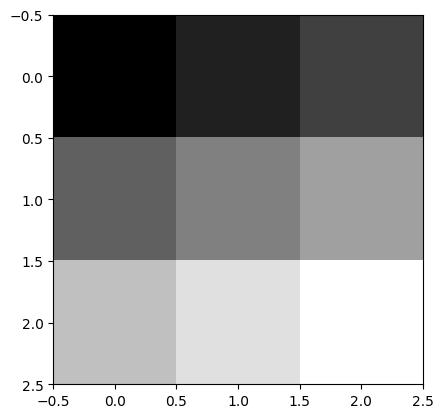

In [77]:
A = np.array([[1,2, 3], [4, 5, 6], [7, 8, 9]])

plt.grid(False) # Används för att stänga av ränder i plotten. Prova gärna hur det blir utan
plt.imshow(A, cmap='gray')


## Transposition

We can now try to transpose the matrix A.

$A^T = \begin{bmatrix}
1 & 4 & 7 \\
2 & 5 & 8 \\
3 & 6 & 9 \\
\end{bmatrix}
$

In Python, you get the transpose of a matrix by $.T$, so in this case `A.T`



### **8. Exercise:** Transpose a matrix.

Create the transposition with Numpy, and look at the result by displaying the new matrix with *plt.imshow*

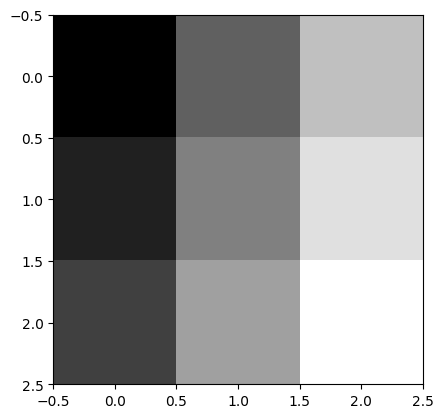

In [79]:
 # Put your code here
A = np.array([[1,2, 3], [4, 5, 6], [7, 8, 9]])

plt.grid(False) # Används för att stänga av ränder i plotten. Prova gärna hur det blir utan
plt.imshow(A.T, cmap='gray')

## Same thing with images!
In [a previous example](#scrollTo=QVTvT92A6KTP) we loaded an image of an owl. What we did then was load it as a large matrix. You will now perform the same operation as in the example above, but on the image instead.



### **9. Exercise:** Working with images

**a)** Use plt.imshow to display a rotated image of the owl from above.

**b)** Apply the following three manipulations to the rotated image and plot the outcome for each of the three:

[numpy.flip](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.flip.html) to flip the image around an axis

`image[::-1]` to mirror the image

`image[image > 100] = 0` where you set all values ​​that are above 100 to 0.

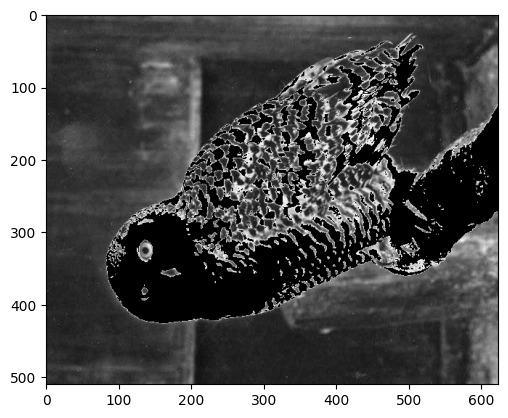

In [113]:
import imageio.v2 as imageio
 # Put your code here

bild = imageio.imread('/content/sample_data/uggla.tif')
bild_roterad = bild.T
plt.imshow(bild_roterad, cmap='gray')

#flipped_bild = np.flip(bild_roterad, 0)

#plt.imshow(flipped_bild, cmap='gray')

spegel_bild = bild_roterad[::-1]

#plt.imshow(spegel_bild,cmap = "gray")

mörk_bild = bild_roterad.copy()

mörk_bild[mörk_bild > 100] = 0
plt.imshow(mörk_bild, cmap='gray')



## Color Images

Color images are not much different from grayscale images, but instead of a 2D matrix, a 3D matrix is ​​used, where each dimension contains information about the amount of red, green, and blue instead of just one value between black and white.

![alt text](https://www.dropbox.com/s/ve8ocuzx6amg41f/Figure1.png?dl=1)


## **10. Exercise:** Remove a color from an image

Now display the image bbridge-cut.jpg using imshow. _Don't_ use cmap='gray' now!

Using everything you've learned above, as a final task, remove the red color from the image above. The operation should be possible to do in one line of code! (except for one line to load the image and one to display it)

(479, 1024, 3)


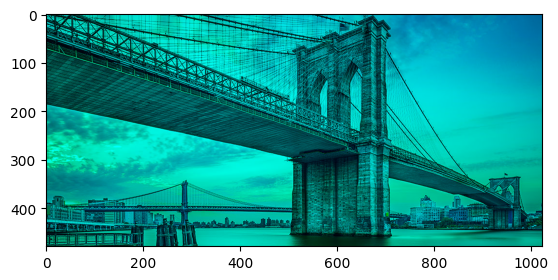

In [125]:
 # Put your code here
import imageio.v2 as imageio
bild = imageio.imread('/content/sample_data/bbridge-cut.jpg')

print(bild.shape)

bild[:, :, 0] = 0


plt.imshow(bild)



